In [ ]:
import zipfile, os, glob

ARCHIVE = r"E:/Spbu_ML/spbu_dl_2025/my_homework/dz_3/dataverse_files.zip"
WORKDIR = r"E:/Spbu_ML/spbu_dl_2025/my_homework/dz_3/dataverse_unpack"
os.makedirs(WORKDIR, exist_ok=True)

with zipfile.ZipFile(ARCHIVE) as z:
    z.extractall(WORKDIR)

TEXTS_ZIP = os.path.join(WORKDIR, "texts.zip")
OUT_TEXTS = os.path.join(WORKDIR, "texts")
os.makedirs(OUT_TEXTS, exist_ok=True)

with zipfile.ZipFile(TEXTS_ZIP) as z:
    z.extractall(OUT_TEXTS)

files = sorted(glob.glob(os.path.join(OUT_TEXTS, "*.txt")))
print("texts:", len(files), "example:", files[0])


texts: 913 example: E:/Spbu_ML/spbu_dl_2025/my_homework/dz_3/dataverse_unpack\texts\A1.txt


In [19]:
import regex as re

PATTERN = re.compile(
    r"'s|'t|'re|'ve|'m|'ll|'d| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+"
)

def pretokenize(text: str):
    return PATTERN.findall(text)


In [ ]:
from collections import Counter
import numpy as np
import random
import regex as re

def bytes_to_unicode():
    bs = list(range(ord("!"), ord("~")+1)) + list(range(ord("¡"), ord("¬")+1)) + list(range(ord("®"), ord("ÿ")+1))
    cs = bs[:]
    n = 0
    for b in range(256):
        if b not in bs:
            bs.append(b)
            cs.append(256+n)
            n += 1
    cs = [chr(c) for c in cs]
    return dict(zip(bs, cs))

BYTE_ENCODER = bytes_to_unicode()
BYTE_DECODER = {v: k for k, v in BYTE_ENCODER.items()}

PATTERN = re.compile(r"'s|'t|'re|'ve|'m|'ll|'d| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+")

def pretokenize(text: str):
    return PATTERN.findall(text)

def token_to_symbols(tok: str):
    b = tok.encode("utf-8")
    return tuple(BYTE_ENCODER[bb] for bb in b)

def get_pair_stats(vocab_counts: Counter):
    pairs = Counter()
    for symbols, freq in vocab_counts.items():
        for i in range(len(symbols)-1):
            pairs[(symbols[i], symbols[i+1])] += freq
    return pairs

def merge_pair(pair, vocab_counts: Counter):
    a, b = pair
    new_counts = Counter()
    for symbols, freq in vocab_counts.items():
        if len(symbols) < 2:
            new_counts[symbols] += freq
            continue
        out = []
        i = 0
        while i < len(symbols):
            if i < len(symbols)-1 and symbols[i] == a and symbols[i+1] == b:
                out.append(a + b)
                i += 2
            else:
                out.append(symbols[i])
                i += 1
        new_counts[tuple(out)] += freq
    return new_counts

def train_bpe(texts, vocab_size=8000, special_tokens=None):
    if special_tokens is None:
        special_tokens = ["<pad>", "<bos>", "<eos>", "<unk>"]

    vocab_counts = Counter()
    for text in texts:
        for tok in pretokenize(text):
            vocab_counts[token_to_symbols(tok)] += 1

    merges = []
    target_merges = max(0, vocab_size - len(special_tokens) - 256)

    for _ in range(target_merges):
        pairs = get_pair_stats(vocab_counts)
        if not pairs:
            break
        best_pair, best_freq = pairs.most_common(1)[0]
        if best_freq < 2:
            break
        vocab_counts = merge_pair(best_pair, vocab_counts)
        merges.append(best_pair)

    bpe_ranks = {p: i for i, p in enumerate(merges)}

    vocab = {}
    for i, st in enumerate(special_tokens):
        vocab[st] = i
    offset = len(vocab)

    for _, ch in BYTE_ENCODER.items():
        vocab[ch] = offset
        offset += 1

    for a, b in merges:
        merged = a + b
        if merged not in vocab:
            vocab[merged] = offset
            offset += 1

    return vocab, bpe_ranks, special_tokens

def bpe_encode_symbols(symbols, bpe_ranks):
    symbols = list(symbols)
    if len(symbols) <= 1:
        return symbols

    while True:
        pairs = [(symbols[i], symbols[i+1]) for i in range(len(symbols)-1)]
        best = None
        best_rank = None
        for p in pairs:
            r = bpe_ranks.get(p)
            if r is not None and (best_rank is None or r < best_rank):
                best_rank = r
                best = p
        if best is None:
            break

        a, b = best
        out = []
        i = 0
        while i < len(symbols):
            if i < len(symbols)-1 and symbols[i] == a and symbols[i+1] == b:
                out.append(a + b)
                i += 2
            else:
                out.append(symbols[i])
                i += 1
        symbols = out
        if len(symbols) == 1:
            break

    return symbols

class BPETokenizer:
    def __init__(self, vocab, bpe_ranks, special_tokens):
        self.vocab = vocab
        self.bpe_ranks = bpe_ranks
        self.special_tokens = set(special_tokens)
        self.unk = "<unk>"
        self.bos = "<bos>"
        self.eos = "<eos>"
        self.inv_vocab = {i: t for t, i in vocab.items()}

    def encode(self, text: str, add_special_tokens=False):
        ids = []
        if add_special_tokens:
            ids.append(self.vocab[self.bos])

        for tok in pretokenize(text):
            syms = token_to_symbols(tok)
            pieces = bpe_encode_symbols(syms, self.bpe_ranks)
            for p in pieces:
                ids.append(self.vocab.get(p, self.vocab[self.unk]))

        if add_special_tokens:
            ids.append(self.vocab[self.eos])
        return ids

    def decode(self, ids, skip_special_tokens=True):
        s = []
        for i in ids:
            t = self.inv_vocab.get(i, self.unk)
            if skip_special_tokens and t in self.special_tokens:
                continue
            s.append(t)
        byte_stream = bytes([BYTE_DECODER[c] for c in "".join(s)])
        return byte_stream.decode("utf-8", errors="replace")


In [21]:
import glob, os, random

def load_texts(texts_dir):
    paths = sorted(glob.glob(os.path.join(texts_dir, "*.txt")))
    return [open(p, encoding="utf-8").read() for p in paths]

texts = load_texts(OUT_TEXTS)

random.seed(42)
idx = list(range(len(texts)))
random.shuffle(idx)
train_texts = [texts[i] for i in idx[:700]]
test_texts  = [texts[i] for i in idx[700:]]

vocab, ranks, specials = train_bpe(train_texts, vocab_size=8000)
tok = BPETokenizer(vocab, ranks, specials)

print("vocab size:", len(vocab))
print(tok.decode(tok.encode("Привет, мир!")))


vocab size: 8000
Привет, мир!


In [ ]:
import regex as re
from collections import Counter
import numpy as np
import random

WORD_RE = re.compile(r"\p{L}+")

def compute_metrics(tokenizer, texts, word_sample_cap=50000):
    total_tokens = 0
    total_bytes = 0
    total_chars = 0

    word_freq = Counter()

    for t in texts:
        ids = tokenizer.encode(t, add_special_tokens=False)
        total_tokens += len(ids)
        total_bytes += len(t.encode("utf-8"))
        total_chars += len(t)

        words = WORD_RE.findall(t.lower())
        word_freq.update(words)

    all_words = list(word_freq.elements())
    if len(all_words) > word_sample_cap:
        all_words = random.sample(all_words, word_sample_cap)

    tpw = [len(tokenizer.encode(" " + w, add_special_tokens=False)) for w in all_words]
    avg_tpw = float(np.mean(tpw)) if tpw else 0.0

    uniq = len(word_freq)
    topn = max(1, int(uniq * 0.10))
    top_words = [w for w, _ in word_freq.most_common(topn)]
    top_tpw = [len(tokenizer.encode(" " + w, add_special_tokens=False)) for w in top_words]
    avg_top_tpw = float(np.mean(top_tpw)) if top_tpw else 0.0

    return {
        "tokens": total_tokens,
        "bytes": total_bytes,
        "chars": total_chars,
        "tokens_per_byte": total_tokens / total_bytes,
        "tokens_per_char": total_tokens / total_chars,
        "avg_tokens_per_word": avg_tpw,
        "avg_tokens_per_word_top10pct": avg_top_tpw,
        "unique_words": uniq,
    }

m_test = compute_metrics(tok, test_texts)
m_train = compute_metrics(tok, train_texts)

print("TEST:", m_test)
print("TRAIN:", m_train)


TEST: {'tokens': 58030, 'bytes': 296833, 'chars': 168196, 'tokens_per_byte': 0.19549713138363997, 'tokens_per_char': 0.34501415015814885, 'avg_tokens_per_word': 1.5981990027535908, 'avg_tokens_per_word_top10pct': 1.2461977186311788, 'unique_words': 10526}
TRAIN: {'tokens': 178335, 'bytes': 976151, 'chars': 551758, 'tokens_per_byte': 0.18269202203347637, 'tokens_per_char': 0.32321235034199775, 'avg_tokens_per_word': 1.4954, 'avg_tokens_per_word_top10pct': 1.1255645889792232, 'unique_words': 22144}


In [ ]:

domain_a_name = "Pushkin (held-out test_texts)"
domain_a_texts = test_texts

OTHER_TEXTS_DIR = None  

def load_texts_from_dir(texts_dir):
    import glob, os
    paths = sorted(glob.glob(os.path.join(texts_dir, "*.txt")))
    texts = []
    for p in paths:
        with open(p, encoding="utf-8") as f:
            texts.append(f.read())
    return texts

if OTHER_TEXTS_DIR is not None:
    domain_b_name = f"Other domain from dir: {OTHER_TEXTS_DIR}"
    domain_b_texts = load_texts_from_dir(OTHER_TEXTS_DIR)
else:
    
    domain_b_name = "Other domain (news/tech sample)"
    domain_b_texts = [
        "Компания представила обновление программного обеспечения. "
        "В релизе исправлены уязвимости, оптимизирована работа с памятью и добавлены новые API. "
        "Рекомендуется обновить систему до версии 2.3.1.",

        "Согласно отчёту, инфляция в годовом выражении составила 7,2%. "
        "Эксперты отмечают рост цен на услуги и увеличение потребительского спроса. "
        "В ближайшие месяцы ожидается изменение ключевой ставки.",

        "Для развертывания сервиса необходимо настроить переменные окружения, "
        "запустить миграции базы данных и выполнить сборку контейнера. "
        "Параметры конфигурации указаны в документации проекта."
    ]

m_a = compute_metrics(tok, domain_a_texts)
m_b = compute_metrics(tok, domain_b_texts)

def pack_required(m):
    return {
        "tokens_per_byte": m["tokens_per_byte"],   
        "tokens_per_char": m["tokens_per_char"],   
        "avg_tokens_per_word": m["avg_tokens_per_word"],
        "avg_tokens_per_word_top10pct": m["avg_tokens_per_word_top10pct"],
        "unique_words": m["unique_words"],
    }

print("=== DOMAIN A ===")
print(domain_a_name)
print(pack_required(m_a))

print("\n=== DOMAIN B ===")
print(domain_b_name)
print(pack_required(m_b))

def rel_diff(a, b):
    return (b - a) / a if a != 0 else float("inf")

diff_tpb = rel_diff(m_a["tokens_per_byte"], m_b["tokens_per_byte"])
diff_tpw = rel_diff(m_a["avg_tokens_per_word"], m_b["avg_tokens_per_word"])

print("\n=== DIFFERENCE (B vs A) ===")
print(f"Δ tokens_per_byte: {diff_tpb*100:.2f}%")
print(f"Δ avg_tokens_per_word: {diff_tpw*100:.2f}%")

threshold = 0.05  
differs = (abs(diff_tpb) > threshold) or (abs(diff_tpw) > threshold)

print("\n=== CONCLUSION ===")
if differs:
    print("Да, эффективность токенизации отличается для разных доменов.")
else:
    print("Нет, различия эффективности небольшие (в пределах ~5%).")

better_domain = "DOMAIN B" if m_b["tokens_per_byte"] < m_a["tokens_per_byte"] else "DOMAIN A"
print(f"По метрике tokens_per_byte (меньше = лучше) эффективнее: {better_domain}")


=== DOMAIN A ===
Pushkin (held-out test_texts)
{'tokens_per_byte': 0.19549713138363997, 'tokens_per_char': 0.34501415015814885, 'avg_tokens_per_word': 1.5981990027535908, 'avg_tokens_per_word_top10pct': 1.2461977186311788, 'unique_words': 10526}

=== DOMAIN B ===
Other domain (news/tech sample)
{'tokens_per_byte': 0.20877025738798857, 'tokens_per_char': 0.38488576449912126, 'avg_tokens_per_word': 2.8805970149253732, 'avg_tokens_per_word_top10pct': 2.8333333333333335, 'unique_words': 62}

=== DIFFERENCE (B vs A) ===
Δ tokens_per_byte: 6.79%
Δ avg_tokens_per_word: 80.24%

=== CONCLUSION ===
Да, эффективность токенизации отличается для разных доменов.
По метрике tokens_per_byte (меньше = лучше) эффективнее: DOMAIN A


In [ ]:
import csv

vocab_sizes = [500, 1000, 2000, 4000, 8000]
rows = []

for vs in vocab_sizes:
    vocab, ranks, specials = train_bpe(train_texts, vocab_size=vs)
    tok_vs = BPETokenizer(vocab, ranks, specials)
    met = compute_metrics(tok_vs, test_texts)
    rows.append((vs, met["tokens_per_byte"]))
    print(vs, met["tokens_per_byte"])

with open("vocab_vs_compression.csv", "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["vocab_size", "tokens_per_byte"])
    w.writerows(rows)

print("Saved: vocab_vs_compression.csv")


500 0.3576421759036226
1000 0.2858509667051844
2000 0.24523890537777135
4000 0.2168188846927397
8000 0.19549713138363997
Saved: vocab_vs_compression.csv


500 0.3576421759036226
1000 0.2858509667051844
2000 0.24523890537777135
4000 0.2168188846927397


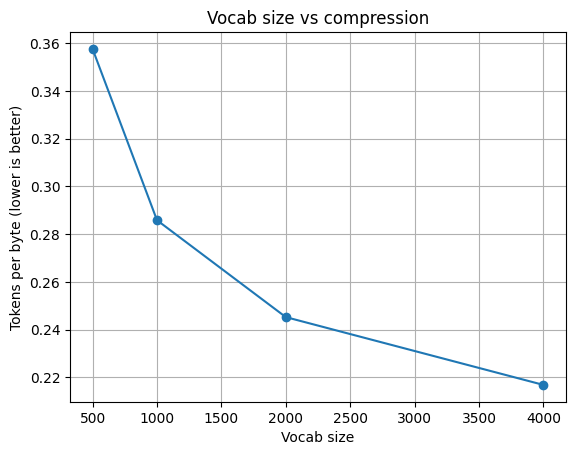

In [26]:
import matplotlib.pyplot as plt

vocab_sizes = [500, 1000, 2000, 4000]
xs, ys = [], []

for vs in vocab_sizes:
    vocab, ranks, specials = train_bpe(train_texts, vocab_size=vs)
    tok_vs = BPETokenizer(vocab, ranks, specials)
    met = compute_metrics(tok_vs, test_texts)

    xs.append(vs)
    ys.append(met["tokens_per_byte"])
    print(vs, met["tokens_per_byte"])

plt.figure()
plt.plot(xs, ys, marker="o")
plt.xlabel("Vocab size")
plt.ylabel("Tokens per byte (lower is better)")
plt.title("Vocab size vs compression")
plt.grid(True)
plt.show()


In [ ]:
def unused_token_fraction(tokenizer, texts):
    used = set()
    for t in texts:
        used.update(tokenizer.encode(t, add_special_tokens=False))

    vocab_size = len(tokenizer.vocab)
    used_count = len(used)

    return {
        "vocab_size": vocab_size,
        "used_tokens": used_count,
        "unused_tokens": vocab_size - used_count,
        "unused_fraction": (vocab_size - used_count) / vocab_size
    }

unused_stats = unused_token_fraction(tok, texts) 
print(unused_stats)


{'vocab_size': 8000, 'used_tokens': 7702, 'unused_tokens': 298, 'unused_fraction': 0.03725}


Задание 1.1

In [19]:
def tokenize_corpus(tokenizer, texts, add_special=True):
    docs = []
    for t in texts:
        ids = tokenizer.encode(t, add_special_tokens=add_special)
        docs.append(ids)
    return docs

train_docs = tokenize_corpus(tok, train_texts, add_special=True)
test_docs  = tokenize_corpus(tok, test_texts, add_special=True)

print(len(train_docs), len(test_docs), "example len:", len(train_docs[0]))


700 213 example len: 40


In [ ]:
import math
import random
from collections import Counter


def tokenize_corpus(tokenizer, texts, add_special=True, min_len=3):
    docs = []
    for t in texts:
        ids = tokenizer.encode(t, add_special_tokens=add_special)
        if len(ids) >= min_len:
            docs.append(ids)
    return docs


def softmax_from_logprobs(logps):
    m = max(logps)
    exps = [math.exp(lp - m) for lp in logps]
    s = sum(exps)
    if s == 0 or not math.isfinite(s):
        n = len(logps)
        return [1.0 / n] * n
    return [e / s for e in exps]

class TrigramLM:
    def __init__(self, vocab_size: int, alpha: float = 0.1):
        self.vocab_size = vocab_size
        self.alpha = alpha
        self.tri = Counter() 
        self.bi = Counter()  
    def fit(self, tokenized_docs):
        for doc in tokenized_docs:
            if len(doc) < 3:
                continue
            for i in range(2, len(doc)):
                h2, h1, w = doc[i-2], doc[i-1], doc[i]
                self.tri[(h2, h1, w)] += 1
                self.bi[(h2, h1)] += 1

    def logprob_next(self, h2, h1, w):
        num = self.tri[(h2, h1, w)] + self.alpha
        den = self.bi[(h2, h1)] + self.alpha * self.vocab_size
        return math.log(num / den)

    def perplexity(self, tokenized_docs):
        total_logp = 0.0
        n = 0
        for doc in tokenized_docs:
            if len(doc) < 3:
                continue
            for i in range(2, len(doc)):
                total_logp += self.logprob_next(doc[i-2], doc[i-1], doc[i])
                n += 1
        if n == 0:
            return float("inf")
        return math.exp(-total_logp / n)

    def generate_greedy(self, tokenizer, max_new_tokens=80, seed_text=""):
        if seed_text.strip():
            prefix = tokenizer.encode(seed_text, add_special_tokens=False)
        else:
            prefix = []

        bos_id = tokenizer.vocab["<bos>"]
        eos_id = tokenizer.vocab["<eos>"]
        V = self.vocab_size

        if len(prefix) == 0:
            seq = [bos_id, bos_id]
        elif len(prefix) == 1:
            seq = [bos_id, prefix[0]]
        else:
            seq = prefix[-2:]

        out = prefix[:] if prefix else []

        for _ in range(max_new_tokens):
            h2, h1 = seq[-2], seq[-1]

            best_w = None
            best_lp = -1e18
            for w in range(V):
                lp = self.logprob_next(h2, h1, w)
                if lp > best_lp:
                    best_lp = lp
                    best_w = w

            if best_w == eos_id:
                break

            out.append(best_w)
            seq.append(best_w)

        return tokenizer.decode(out, skip_special_tokens=True)

    def generate_sample(
        self,
        tokenizer,
        max_new_tokens=80,
        seed_text="",
        temperature=1.0,
        top_k=50,
        no_repeat_trigram=True
    ):
        if seed_text.strip():
            prefix = tokenizer.encode(seed_text, add_special_tokens=False)
        else:
            prefix = []

        bos_id = tokenizer.vocab["<bos>"]
        eos_id = tokenizer.vocab["<eos>"]
        V = self.vocab_size

        if len(prefix) == 0:
            seq = [bos_id, bos_id]
        elif len(prefix) == 1:
            seq = [bos_id, prefix[0]]
        else:
            seq = prefix[-2:]

        out = prefix[:] if prefix else []
        used_trigrams = set()

        for _ in range(max_new_tokens):
            h2, h1 = seq[-2], seq[-1]

            lps = [0.0] * V
            temp = max(temperature, 1e-6)

            for w in range(V):
                lp = self.logprob_next(h2, h1, w)

                if no_repeat_trigram:
                    tri = (h2, h1, w)
                    if tri in used_trigrams:
                        lp = -1e18

                lps[w] = lp / temp

            if top_k is not None and top_k < V:
                idx = sorted(range(V), key=lambda i: lps[i], reverse=True)[:top_k]
            else:
                idx = list(range(V))

            top_lps = [lps[i] for i in idx]
            probs = softmax_from_logprobs(top_lps)

            w = random.choices(idx, weights=probs, k=1)[0]

            if w == eos_id:
                break

            out.append(w)
            used_trigrams.add((h2, h1, w))
            seq.append(w)

        return tokenizer.decode(out, skip_special_tokens=True)

train_docs = tokenize_corpus(tok, train_texts, add_special=True)
test_docs = tokenize_corpus(tok, test_texts, add_special=True)

lm = TrigramLM(vocab_size=len(tok.vocab), alpha=0.1)
lm.fit(train_docs)

ppl_train = lm.perplexity(train_docs)
ppl_test = lm.perplexity(test_docs)

print("Train perplexity:", ppl_train)
print("Test perplexity:", ppl_test)

print("\n--- Greedy generation (may repeat) ---")
print(lm.generate_greedy(tok, max_new_tokens=80, seed_text="Я помню чудное мгновенье"))

print("\n--- Sampling generation (top-k + temperature + no-repeat-trigram) ---")
print(lm.generate_sample(tok, max_new_tokens=80,
                         seed_text="Я помню чудное мгновенье",
                         temperature=1.0, top_k=50, no_repeat_trigram=True))


Train perplexity: 498.632840454849
Test perplexity: 2995.9496938395446

--- Greedy generation (may repeat) ---
Я помню чудное мгновенье.

И в радости немой,
И в радости немой,
И в радости немой,
И в радости немой,
И в радости немой,
И в радости немой,
И в радости немой,
И в радости немой,
И в радости немой,
И в радости немой,
И в радости немой,
И в радости немой,
И в радости немой,

--- Sampling generation (top-k + temperature + no-repeat-trigram) ---
Я помню чудное мгновеньеH2,B+)&K!2H:,2C=+!I4N=K=+3I):;L8G


Задание 1.2

In [7]:
import os, glob, zipfile, random

ARCHIVE = r"E:/Spbu_ML/spbu_dl_2025/my_homework/dz_3/dataverse_files.zip"
WORKDIR = r"E:/Spbu_ML/spbu_dl_2025/my_homework/dz_3/dataverse_unpack"
os.makedirs(WORKDIR, exist_ok=True)

# 1) распаковать внешний архив
with zipfile.ZipFile(ARCHIVE) as z:
    z.extractall(WORKDIR)

# 2) распаковать texts.zip
TEXTS_ZIP = os.path.join(WORKDIR, "texts.zip")
OUT_TEXTS = os.path.join(WORKDIR, "texts")
os.makedirs(OUT_TEXTS, exist_ok=True)

with zipfile.ZipFile(TEXTS_ZIP) as z:
    z.extractall(OUT_TEXTS)

files = sorted(glob.glob(os.path.join(OUT_TEXTS, "*.txt")))
print("texts:", len(files), "example:", files[0])


texts: 913 example: E:/Spbu_ML/spbu_dl_2025/my_homework/dz_3/dataverse_unpack\texts\A1.txt


In [8]:
def load_texts(texts_dir):
    paths = sorted(glob.glob(os.path.join(texts_dir, "*.txt")))
    texts = []
    for p in paths:
        with open(p, encoding="utf-8") as f:
            texts.append(f.read())
    return texts

texts = load_texts(OUT_TEXTS)

random.seed(42)
idx = list(range(len(texts)))
random.shuffle(idx)

train_texts = [texts[i] for i in idx[:700]]
test_texts  = [texts[i] for i in idx[700:]]

print("train:", len(train_texts), "test:", len(test_texts))
print(train_texts[0][:200])


train: 700 test: 213
Накажи, святой угодник,
Капитана Борозду,
Разлюбил он, греховодник,
Нашу матушку <- - - - ->.


In [9]:
TRAIN_CORPUS_PATH = os.path.join(WORKDIR, "train_corpus.txt")

with open(TRAIN_CORPUS_PATH, "w", encoding="utf-8") as out:
    for t in train_texts:
        out.write(t.replace("\n", " ") + "\n")

print("Saved:", TRAIN_CORPUS_PATH)


Saved: E:/Spbu_ML/spbu_dl_2025/my_homework/dz_3/dataverse_unpack\train_corpus.txt


In [10]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.decoders import ByteLevel as ByteLevelDecoder

TOKENIZER_JSON = os.path.join(WORKDIR, "ru_bpe_tokenizer.json")

hf_tokenizer = Tokenizer(BPE(unk_token="<unk>"))
hf_tokenizer.pre_tokenizer = ByteLevel()
hf_tokenizer.decoder = ByteLevelDecoder()

trainer = BpeTrainer(
    vocab_size=8000,
    special_tokens=["<pad>", "<bos>", "<eos>", "<unk>"]
)

hf_tokenizer.train([TRAIN_CORPUS_PATH], trainer)
hf_tokenizer.save(TOKENIZER_JSON)

print("Tokenizer saved:", TOKENIZER_JSON)


Tokenizer saved: E:/Spbu_ML/spbu_dl_2025/my_homework/dz_3/dataverse_unpack\ru_bpe_tokenizer.json


In [11]:
from transformers import GPT2TokenizerFast

tokenizer = GPT2TokenizerFast(
    tokenizer_file=TOKENIZER_JSON,
    bos_token="<bos>",
    eos_token="<eos>",
    unk_token="<unk>",
    pad_token="<pad>"
)

print("Tokenizer vocab size:", len(tokenizer))
print(tokenizer("Я помню чудное мгновенье"))


Tokenizer vocab size: 8000
{'input_ids': [2275, 4631, 1031, 674, 3659, 503], 'attention_mask': [1, 1, 1, 1, 1, 1]}


In [ ]:
from transformers import GPT2LMHeadModel

model = GPT2LMHeadModel.from_pretrained("gpt2")

model.resize_token_embeddings(len(tokenizer))

model.config.pad_token_id = tokenizer.pad_token_id

print("Model loaded. Embeddings resized to:", len(tokenizer))


Model loaded. Embeddings resized to: 8000


In [ ]:
from datasets import Dataset

dataset = Dataset.from_dict({"text": [t.replace("\n", " ") for t in train_texts]})

MAX_LEN = 128

def tokenize_fn(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN
    )

tokenized_ds = dataset.map(tokenize_fn, batched=True, remove_columns=["text"])

def add_labels(examples):
    examples["labels"] = examples["input_ids"].copy()
    return examples

tokenized_ds = tokenized_ds.map(add_labels)

print(tokenized_ds[0].keys())
print("len input_ids:", len(tokenized_ds[0]["input_ids"]))
print("len labels:", len(tokenized_ds[0]["labels"]))


Map: 100%|██████████| 700/700 [00:00<00:00, 9639.01 examples/s]

dict_keys(['input_ids', 'attention_mask', 'labels'])
len input_ids: 128
len labels: 128


In [14]:
from transformers import Trainer, TrainingArguments, DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

training_args = TrainingArguments(
    output_dir=os.path.join(WORKDIR, "gpt2-ru-bpe"),
    per_device_train_batch_size=2,
    num_train_epochs=1,
    logging_steps=50,
    save_steps=200,
    save_total_limit=1,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds,
    data_collator=data_collator
)

trainer.train()


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
50,8.047200
100,7.553000
150,7.523200
200,7.501500
250,7.542700
300,7.487600
350,7.447700


TrainOutput(global_step=350, training_loss=7.586119820731027, metrics={'train_runtime': 324.2735, 'train_samples_per_second': 2.159, 'train_steps_per_second': 1.079, 'total_flos': 45726105600000.0, 'train_loss': 7.586119820731027, 'epoch': 1.0})

In [15]:
import torch

prompt = "Я помню чудное мгновенье"
inputs = tokenizer(prompt, return_tensors="pt")

with torch.no_grad():
    out = model.generate(
        **inputs,
        max_length=80,
        do_sample=True,
        top_k=50,
        temperature=0.9,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id
    )

print(tokenizer.decode(out[0], skip_special_tokens=True))


Я помню чудное мгновенье, не [ в, сная я, в, Яю- я,... С На с в, сный — с, я, сный — с?он,ов. Но, на И Но, в он И, с сный — нау он, [ п, сный —я? [ч якный — с,
